<a href="https://colab.research.google.com/github/GodfatherM/Assignments-/blob/main/ayaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
archivo = files.upload()


Saving ave_2.jpg to ave_2.jpg


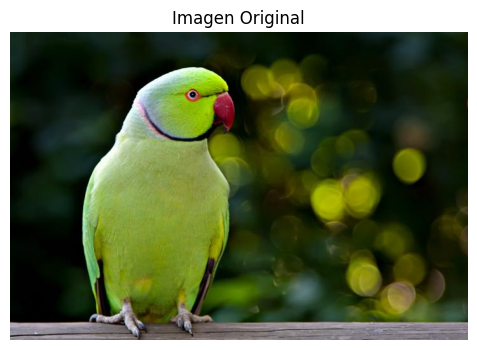

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta_imagen = 'ave_2.jpg'
imagen_original = cv2.imread(ruta_imagen)
imagen_rgb = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 4))
plt.imshow(imagen_rgb)
plt.title('Imagen Original')
plt.axis('off')
plt.show()


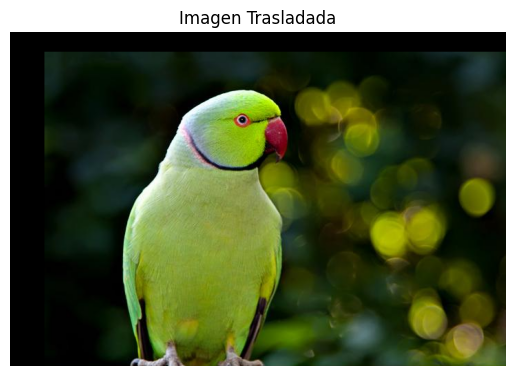

In [4]:
filas, columnas = imagen_original.shape[:2]
M_traslacion = np.float32([[1, 0, 50], [0, 1, 30]])
imagen_trasladada = cv2.warpAffine(imagen_original, M_traslacion, (columnas, filas))

plt.imshow(cv2.cvtColor(imagen_trasladada, cv2.COLOR_BGR2RGB))
plt.title('Imagen Trasladada')
plt.axis('off')
plt.show()


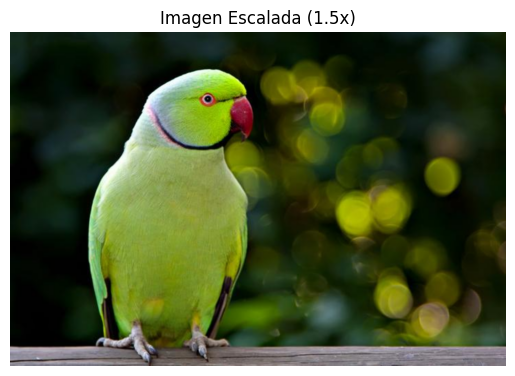

In [5]:
imagen_escalada = cv2.resize(imagen_original, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)

plt.imshow(cv2.cvtColor(imagen_escalada, cv2.COLOR_BGR2RGB))
plt.title('Imagen Escalada (1.5x)')
plt.axis('off')
plt.show()


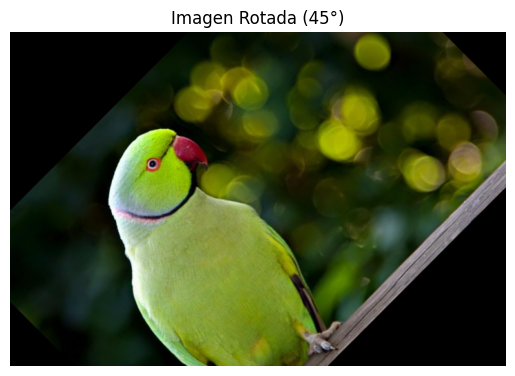

In [6]:
centro = (columnas // 2, filas // 2)
matriz_rotacion = cv2.getRotationMatrix2D(centro, 45, 1)
imagen_rotada = cv2.warpAffine(imagen_original, matriz_rotacion, (columnas, filas))

plt.imshow(cv2.cvtColor(imagen_rotada, cv2.COLOR_BGR2RGB))
plt.title('Imagen Rotada (45°)')
plt.axis('off')
plt.show()


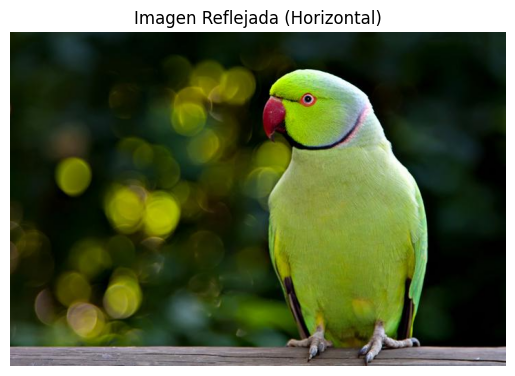

In [11]:
imagen_reflejada = cv2.flip(imagen_original, 1)

plt.imshow(cv2.cvtColor(imagen_reflejada, cv2.COLOR_BGR2RGB))
plt.title('Imagen Reflejada (Horizontal)')
plt.axis('off')
plt.show()


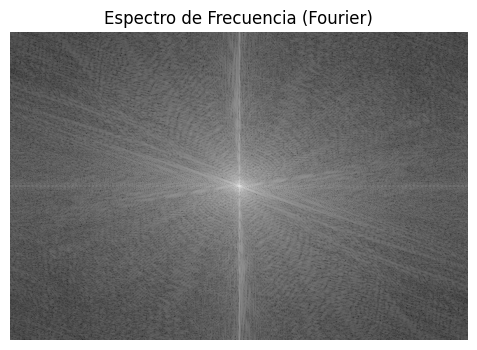

In [12]:

imagen_gris = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2GRAY)

dft = cv2.dft(np.float32(imagen_gris), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_trasladado = np.fft.fftshift(dft)

magnitud = cv2.magnitude(dft_trasladado[:,:,0], dft_trasladado[:,:,1])
espectro = 20 * np.log(1 + magnitud)

plt.figure(figsize=(6, 4))
plt.imshow(espectro, cmap='gray')
plt.title('Espectro de Frecuencia (Fourier)')
plt.axis('off')
plt.show()


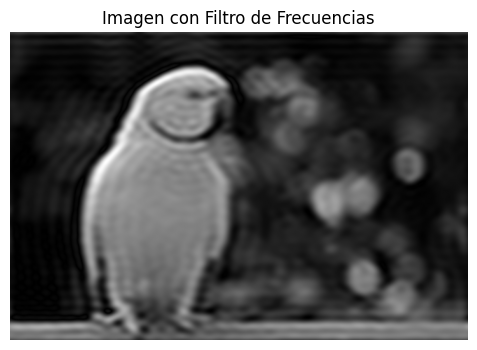

In [13]:

filas, columnas = imagen_gris.shape
centro_fila, centro_col = filas // 2, columnas // 2
mascara = np.zeros((filas, columnas, 2), np.uint8)
tam_bloque = 30
mascara[centro_fila-tam_bloque:centro_fila+tam_bloque, centro_col-tam_bloque:centro_col+tam_bloque] = 1

dft_filtrado = dft_trasladado * mascara

dft_inv = np.fft.ifftshift(dft_filtrado)
imagen_filtrada = cv2.idft(dft_inv)
imagen_filtrada = cv2.magnitude(imagen_filtrada[:,:,0], imagen_filtrada[:,:,1])

plt.figure(figsize=(6,4))
plt.imshow(imagen_filtrada, cmap='gray')
plt.title('Imagen con Filtro de Frecuencias')
plt.axis('off')
plt.show()
